# 🤖 SVM (Support Vector Machine) Regression Tutorial for Turbofan Engine RUL Prediction

## Learning Objectives

By the end of this tutorial, you will:
- Understand what SVM/SVR is and how it differs from Linear Regression
- Learn about support vectors and the margin concept
- Understand different kernel functions (linear, RBF, polynomial)
- Learn about hyperparameters (C, epsilon, gamma) and how to tune them
- Understand epsilon-insensitive loss function
- Train and evaluate an SVR model
- Compare SVR with Linear Regression
- Visualize predictions and understand model behavior

---

## What is SVM (Support Vector Machine)?

**Support Vector Machine (SVM)** is a powerful machine learning algorithm that can handle both **classification** and **regression** tasks.

For regression, we use **SVR (Support Vector Regression)**.

### The Basic Idea:

Unlike Linear Regression which tries to fit a line through all points, SVR:
- Tries to fit a **tube** (called an epsilon-tube) around the data
- Only cares about points **outside** this tube (errors)
- Uses only a subset of data points called **Support Vectors**

### Key Concepts:

#### 1. Epsilon-Tube (ε-tube):
- A "margin of tolerance" around the prediction line
- Points **inside** the tube are considered correct (no penalty)
- Points **outside** the tube contribute to the loss
- Think of it as: "Close enough is good enough"

#### 2. Support Vectors:
- Data points that lie **on or outside** the epsilon-tube
- These are the "important" points that define the model
- Only these points affect the final model
- Usually much fewer than total data points (memory efficient!)

#### 3. Kernel Functions:
- Transform data into higher dimensions
- Allows SVR to find **non-linear** relationships
- Common kernels: Linear, RBF (Gaussian), Polynomial

### How SVR Works:

1. **Define epsilon-tube**: Set tolerance for errors (ε)
2. **Find optimal boundary**: Fit a tube that contains most points
3. **Identify support vectors**: Points outside or on the tube
4. **Make predictions**: Use support vectors to predict new values

### Advantages of SVR:
- **Handles non-linear relationships**: With kernel trick
- **Robust to outliers**: Only support vectors matter
- **Memory efficient**: Only stores support vectors
- **Flexible**: Can model complex patterns

### Disadvantages:
- **Slower training**: Especially with large datasets
- **Hyperparameter sensitive**: Need to tune C, epsilon, gamma
- **Less interpretable**: Harder to understand than linear regression

---

## Our Goal: Predict RUL (Remaining Useful Life)

We want to predict **how many cycles** an engine has left before it fails, using SVR instead of Linear Regression.

This will allow us to:
- Capture **non-linear** relationships between sensors and RUL
- Handle complex patterns that linear models might miss
- Compare performance with Linear Regression

## Step 1: Import Required Libraries

Before we start, we need to import the necessary libraries.

### Libraries We'll Use:
- **pandas**: For DataFrames and data manipulation
- **numpy**: For numerical operations
- **matplotlib & seaborn**: For visualizations
- **sklearn**: Scikit-learn - the main machine learning library
  - `SVR`: Our Support Vector Regression model
  - `train_test_split`: To split data into training and validation sets
  - `StandardScaler`: For feature scaling (very important for SVR!)
  - `mean_squared_error`, `mean_absolute_error`, `r2_score`: For evaluation metrics

In [1]:
# Import libraries for data handling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import time  # To measure training time

# Import machine learning components from scikit-learn
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set visualization style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('ggplot')

sns.set_palette("husl")
%matplotlib inline

print("✅ All libraries imported successfully!")
print(f"📦 Pandas version: {pd.__version__}")
print(f"📦 NumPy version: {np.__version__}")
print(f"📦 Scikit-learn version: {__import__('sklearn').__version__}")

✅ All libraries imported successfully!
📦 Pandas version: 2.3.2
📦 NumPy version: 2.2.6
📦 Scikit-learn version: 1.7.2


## Step 2: Load the Dataset

Let's load our turbofan engine dataset. We'll use the same data preparation as the Linear Regression tutorial.

### Note:
SVR is more sensitive to feature scaling than Linear Regression, so proper normalization is **critical**!

In [2]:
# Define the path to our dataset
data_path = Path('dataset/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData')

# Column names
op_settings = ['Altitude', 'Mach', 'TRA']
sensors = ['T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 
           'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']
column_names = ['unit', 'time'] + op_settings + sensors

def load_data(dataset='FD001'):
    """Load training and test data from CSV files"""
    train_file = data_path / f'train_{dataset}.csv'
    test_file = data_path / f'test_{dataset}.csv'
    rul_file = data_path / f'RUL_{dataset}.csv'
    
    # Read CSV files (they already have headers)
    train_df = pd.read_csv(train_file)
    test_df = pd.read_csv(test_file)
    rul_df = pd.read_csv(rul_file)
    
    return train_df, test_df, rul_df

def calculate_rul_train(df):
    """Calculate RUL (Remaining Useful Life) for training data"""
    df = df.copy()
    df['RUL'] = df.groupby('unit')['time'].transform(lambda x: x.max() - x)
    return df

# Load data for FD001 dataset
train_df, test_df, rul_df = load_data('FD001')

# Calculate RUL for training data
train_df = calculate_rul_train(train_df)

print("✅ Data loaded successfully!")
print(f"\n📊 Training data shape: {train_df.shape}")
print(f"📊 Test data shape: {test_df.shape}")
print(f"🚁 Number of engines in training: {train_df['unit'].nunique()}")
print(f"🚁 Number of engines in test: {test_df['unit'].nunique()}")

✅ Data loaded successfully!

📊 Training data shape: (20631, 27)
📊 Test data shape: (13096, 26)
🚁 Number of engines in training: 100
🚁 Number of engines in test: 100


## Step 3: Prepare Features and Target

We'll prepare the data the same way as Linear Regression, but remember:
- SVR is **very sensitive** to feature scaling
- We'll use a sample of data for faster training (SVR can be slow on large datasets)
- We'll prepare both full and sampled datasets

In [3]:
# Select features (X) - everything except unit and RUL
feature_columns = op_settings + sensors + ['time']

# Prepare training features (X) and target (y)
X_train_full = train_df[feature_columns].copy()
y_train_full = train_df['RUL'].copy()

# For faster training, let's use a sample (SVR can be slow on large datasets)
# We'll sample 5000 rows for initial training
sample_size = min(5000, len(X_train_full))
sample_indices = np.random.choice(len(X_train_full), sample_size, replace=False)
X_train = X_train_full.iloc[sample_indices].copy()
y_train = y_train_full.iloc[sample_indices].copy()

print("✅ Features and target prepared!")
print(f"\n📊 Full training data: {X_train_full.shape[0]:,} samples")
print(f"📊 Sampled training data: {X_train.shape[0]:,} samples (for faster training)")
print(f"📊 Number of features: {X_train.shape[1]}")
print(f"\n💡 Note: Using sample for faster training. For production, use full dataset.")

✅ Features and target prepared!

📊 Full training data: 20,631 samples
📊 Sampled training data: 5,000 samples (for faster training)
📊 Number of features: 25

💡 Note: Using sample for faster training. For production, use full dataset.


In [4]:
# Prepare test data - get last timestep for each engine
test_last_indices = test_df.groupby('unit')['time'].idxmax().values
X_test = test_df.loc[test_last_indices, feature_columns].reset_index(drop=True)
y_test = rul_df['RUL'].values

print("✅ Test data prepared!")
print(f"\n📊 Test Features shape: {X_test.shape}")
print(f"📊 Test Target shape: {y_test.shape}")

✅ Test data prepared!

📊 Test Features shape: (100, 25)
📊 Test Target shape: (100,)


## Step 4: Feature Scaling (CRITICAL for SVR!)

### Why Scaling is Critical for SVR:

SVR uses **distance-based calculations** (especially with RBF kernel). If features have different scales:
- Features with larger values dominate
- The model can't learn properly
- Training becomes unstable

### Example:
- Temperature: 500-1600 (large values)
- Pressure: 10-600 (medium values)
- Time: 1-300 (small values)

Without scaling, temperature would completely dominate!

### Solution: StandardScaler

We'll use **StandardScaler** which:
- Centers data: mean = 0
- Scales to unit variance: std = 1
- Formula: `(x - mean) / std`

### Important:
- **Fit** scaler on training data only
- **Transform** both training and test data
- Never fit on test data!

In [5]:
# Create scalers for features and target
scaler_X = StandardScaler()

# Fit scaler on TRAINING data only
X_train_scaled = scaler_X.fit_transform(X_train)

# Transform test data using the SAME scaler
X_test_scaled = scaler_X.transform(X_test)

print("✅ Data scaled successfully!")
print(f"\n📊 Before scaling (sample - first feature 'Altitude'):")
print(f"   Min: {X_train['Altitude'].min():.4f}")
print(f"   Max: {X_train['Altitude'].max():.4f}")
print(f"   Mean: {X_train['Altitude'].mean():.4f}")
print(f"   Std: {X_train['Altitude'].std():.4f}")

print(f"\n📊 After scaling (first feature):")
print(f"   Min: {X_train_scaled[:, 0].min():.4f}")
print(f"   Max: {X_train_scaled[:, 0].max():.4f}")
print(f"   Mean: {X_train_scaled[:, 0].mean():.4f}")
print(f"   Std: {X_train_scaled[:, 0].std():.4f}")

print("\n💡 Notice: After scaling, mean ≈ 0 and std ≈ 1")

✅ Data scaled successfully!

📊 Before scaling (sample - first feature 'Altitude'):
   Min: -0.0081
   Max: 0.0083
   Mean: -0.0000
   Std: 0.0022

📊 After scaling (first feature):
   Min: -3.7428
   Max: 3.8380
   Mean: 0.0000
   Std: 1.0000

💡 Notice: After scaling, mean ≈ 0 and std ≈ 1


In [6]:
# Split training data into train and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_scaled, y_train, 
    test_size=0.2, 
    random_state=42
)

print("✅ Data split successfully!")
print(f"\n📊 Training set: {X_train_split.shape[0]:,} samples")
print(f"📊 Validation set: {X_val_split.shape[0]:,} samples")
print(f"📊 Test set: {X_test_scaled.shape[0]} samples")

✅ Data split successfully!

📊 Training set: 4,000 samples
📊 Validation set: 1,000 samples
📊 Test set: 100 samples


## Step 5: Understanding SVR Hyperparameters

SVR has several important hyperparameters that control its behavior. Understanding these is crucial!

### Key Hyperparameters:

#### 1. **C (Regularization Parameter)**

**What it does**: Controls the trade-off between:
- **Fitting the training data well** (low error)
- **Keeping the model simple** (generalization)

**Values**:
- **Small C** (e.g., 0.1, 1): 
  - More regularization
  - Simpler model
  - May underfit (high bias)
  - More support vectors

- **Large C** (e.g., 100, 1000):
  - Less regularization
  - Complex model
  - May overfit (high variance)
  - Fewer support vectors

**Default**: C=1.0

#### 2. **epsilon (ε) - Epsilon-Tube Width**

**What it does**: Defines the width of the "tolerance tube"

**How it works**:
- Points **inside** the tube (within ε distance) = no penalty
- Points **outside** the tube = contribute to loss

**Values**:
- **Small epsilon** (e.g., 0.01, 0.1):
  - Tight tube
  - More support vectors
  - Model tries to fit data closely
  - May overfit

- **Large epsilon** (e.g., 1.0, 10.0):
  - Wide tube
  - Fewer support vectors
  - Model is more tolerant of errors
  - May underfit

**Default**: epsilon=0.1

#### 3. **kernel - Kernel Function**

**What it does**: Transforms data to find non-linear relationships

**Options**:

1. **'linear'**: 
   - No transformation
   - Finds linear relationships
   - Fastest
   - Similar to Linear Regression

2. **'rbf'** (Radial Basis Function / Gaussian):
   - Most common for non-linear problems
   - Creates smooth, curved boundaries
   - Requires **gamma** parameter
   - Good default choice

3. **'poly'** (Polynomial):
   - Finds polynomial relationships
   - Requires **degree** parameter
   - Can be slow

4. **'sigmoid'**:
   - Less common
   - Similar to neural network activation

**Default**: kernel='rbf'

#### 4. **gamma - RBF Kernel Parameter**

**What it does**: Controls the "reach" of each support vector (only for RBF kernel)

**Values**:
- **Small gamma** (e.g., 0.001, 0.01):
  - Large influence radius
  - Smoother decision boundary
  - More support vectors
  - May underfit

  - **Large gamma** (e.g., 1.0, 10.0):
  - Small influence radius
  - More complex boundaries
  - Fewer support vectors
  - May overfit

**Default**: gamma='scale' (1 / (n_features × X.var()))

### Summary Table:

| Hyperparameter | Low Value | High Value | Effect |
|---------------|-----------|------------|--------|
| **C** | Simple model, may underfit | Complex model, may overfit | Regularization |
| **epsilon** | Tight fit, many SVs | Loose fit, few SVs | Tolerance |
| **gamma** (RBF) | Smooth, large radius | Complex, small radius | Kernel reach |

### How to Choose?

1. **Start with defaults**: kernel='rbf', C=1.0, epsilon=0.1
2. **Try different kernels**: linear vs rbf vs poly
3. **Tune C and epsilon**: Use validation set to find best values
4. **Use GridSearchCV**: Automatically find best hyperparameters

## Step 6: Understanding Epsilon-Insensitive Loss Function

SVR uses a special loss function called **epsilon-insensitive loss** (also called **Huber loss** for regression).

### How It Works:

```
Loss = 0, if |predicted - actual| ≤ epsilon
Loss = |predicted - actual| - epsilon, if |predicted - actual| > epsilon
```

### Visual Explanation:

Imagine a tube around the prediction line:
- **Inside the tube** (within ε distance): Loss = 0 ✅
- **Outside the tube**: Loss = distance beyond epsilon

### Example:

If epsilon = 5:
- Actual = 100, Predicted = 102 → Error = 2 → **Inside tube** → Loss = 0 ✅
- Actual = 100, Predicted = 108 → Error = 8 → **Outside tube** → Loss = 8 - 5 = 3
- Actual = 100, Predicted = 95 → Error = 5 → **On boundary** → Loss = 0 ✅
- Actual = 100, Predicted = 90 → Error = 10 → **Outside tube** → Loss = 10 - 5 = 5

### Why This Loss Function?

1. **Robust to small errors**: Small errors don't matter (within epsilon)
2. **Focus on large errors**: Only penalizes significant mistakes
3. **Sparse solution**: Only support vectors (points outside tube) matter
4. **Memory efficient**: Model only stores support vectors

### Comparison with MSE:

**MSE (used in Linear Regression)**:
- Penalizes ALL errors, even tiny ones
- Squared, so large errors are heavily penalized
- Uses ALL data points

**Epsilon-Insensitive Loss (SVR)**:
- Ignores small errors (within epsilon)
- Linear penalty for large errors
- Uses only support vectors

### The Complete SVR Objective:

SVR tries to minimize:
```
Minimize: (1/2)||w||² + C × Σ(ξ + ξ*)
```

Where:
- `||w||²`: Model complexity (smaller is simpler)
- `C`: Regularization parameter
- `ξ, ξ*`: Slack variables (errors outside epsilon-tube)

This balances:
- **Simplicity** (small ||w||²)
- **Accuracy** (small errors)

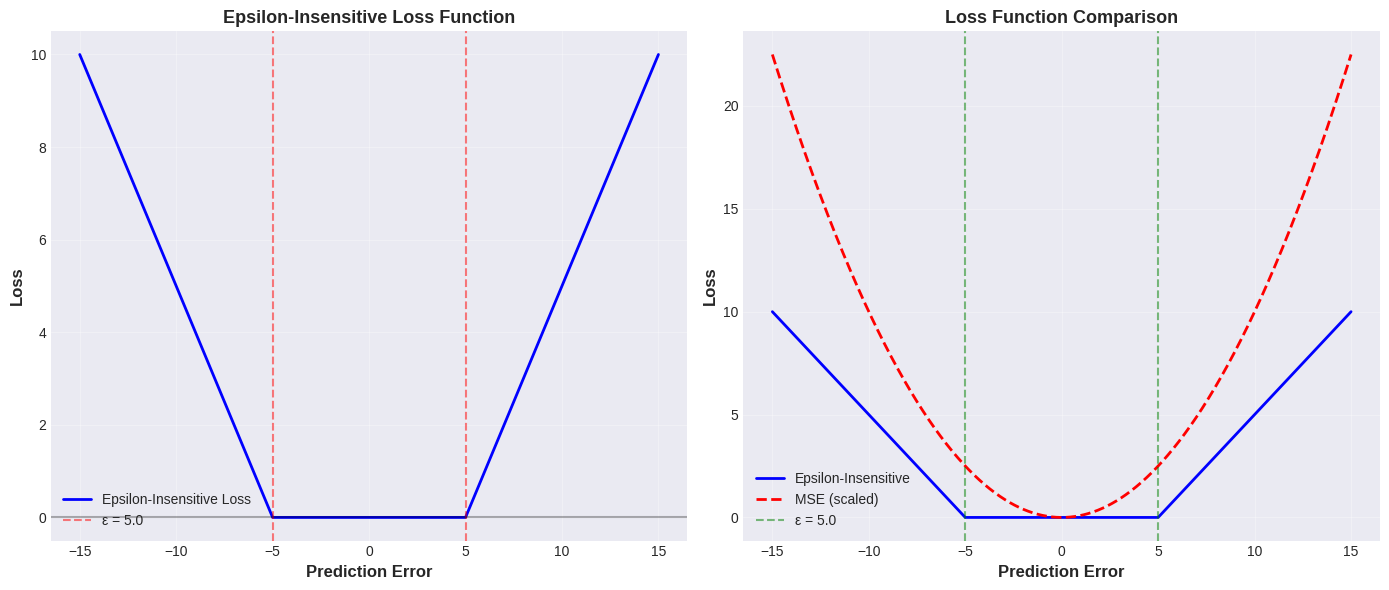

✅ Loss function visualization created!

💡 Key Observations:
   - Errors within ±5.0 have ZERO loss (green zone)
   - Only errors outside epsilon-tube contribute to loss
   - Linear penalty (not squared like MSE)
   - More tolerant of small errors than MSE


In [7]:
# Let's visualize epsilon-insensitive loss

# Create example errors
errors = np.linspace(-15, 15, 1000)
epsilon = 5.0

# Calculate epsilon-insensitive loss
epsilon_loss = np.maximum(0, np.abs(errors) - epsilon)

# Calculate MSE for comparison
mse_loss = errors ** 2

# Plot comparison
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(errors, epsilon_loss, 'b-', linewidth=2, label='Epsilon-Insensitive Loss')
plt.axvline(x=epsilon, color='r', linestyle='--', alpha=0.5, label=f'ε = {epsilon}')
plt.axvline(x=-epsilon, color='r', linestyle='--', alpha=0.5)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('Prediction Error', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.title('Epsilon-Insensitive Loss Function', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.fill_between(errors, 0, epsilon_loss, where=(np.abs(errors) <= epsilon), 
                 alpha=0.3, color='green', label='Zero Loss Zone')

plt.subplot(1, 2, 2)
plt.plot(errors, epsilon_loss, 'b-', linewidth=2, label='Epsilon-Insensitive')
plt.plot(errors, mse_loss / 10, 'r--', linewidth=2, label='MSE (scaled)')
plt.axvline(x=epsilon, color='g', linestyle='--', alpha=0.5, label=f'ε = {epsilon}')
plt.axvline(x=-epsilon, color='g', linestyle='--', alpha=0.5)
plt.xlabel('Prediction Error', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.title('Loss Function Comparison', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Loss function visualization created!")
print("\n💡 Key Observations:")
print(f"   - Errors within ±{epsilon} have ZERO loss (green zone)")
print("   - Only errors outside epsilon-tube contribute to loss")
print("   - Linear penalty (not squared like MSE)")
print("   - More tolerant of small errors than MSE")

## Step 7: Create and Train SVR Models with Different Kernels

Let's create SVR models with different kernels and compare them!

### We'll Try:
1. **Linear Kernel**: Simple, fast, linear relationships
2. **RBF Kernel**: Most common, handles non-linear relationships
3. **Polynomial Kernel**: For polynomial relationships

### Training Strategy:
- Start with default hyperparameters
- Train each kernel type
- Compare performance
- Choose the best one

In [8]:
# Create SVR models with different kernels

print("🚀 Creating SVR models with different kernels...")
print("=" * 80)

# Model 1: Linear Kernel
print("\n1️⃣  Training Linear SVR...")
start_time = time.time()
svr_linear = SVR(kernel='linear', C=1.0, epsilon=0.1)
svr_linear.fit(X_train_split, y_train_split)
linear_time = time.time() - start_time
print(f"   ✅ Trained in {linear_time:.2f} seconds")

# Model 2: RBF Kernel (default, most common)
print("\n2️⃣  Training RBF SVR...")
start_time = time.time()
svr_rbf = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
svr_rbf.fit(X_train_split, y_train_split)
rbf_time = time.time() - start_time
print(f"   ✅ Trained in {rbf_time:.2f} seconds")

# Model 3: Polynomial Kernel
print("\n3️⃣  Training Polynomial SVR...")
start_time = time.time()
svr_poly = SVR(kernel='poly', C=1.0, epsilon=0.1, degree=3, gamma='scale')
svr_poly.fit(X_train_split, y_train_split)
poly_time = time.time() - start_time
print(f"   ✅ Trained in {poly_time:.2f} seconds")

print("\n✅ All models trained successfully!")
print(f"\n⏱️  Training Times:")
print(f"   Linear: {linear_time:.2f}s")
print(f"   RBF: {rbf_time:.2f}s")
print(f"   Polynomial: {poly_time:.2f}s")

🚀 Creating SVR models with different kernels...

1️⃣  Training Linear SVR...
   ✅ Trained in 0.48 seconds

2️⃣  Training RBF SVR...
   ✅ Trained in 0.57 seconds

3️⃣  Training Polynomial SVR...
   ✅ Trained in 0.51 seconds

✅ All models trained successfully!

⏱️  Training Times:
   Linear: 0.48s
   RBF: 0.57s
   Polynomial: 0.51s


In [9]:
# Check number of support vectors for each model
print("📊 Support Vectors Information:")
print("=" * 80)
print(f"\nLinear SVR:")
print(f"   Number of support vectors: {len(svr_linear.support_vectors_):,}")
print(f"   Percentage of training data: {len(svr_linear.support_vectors_)/len(X_train_split)*100:.1f}%")

print(f"\nRBF SVR:")
print(f"   Number of support vectors: {len(svr_rbf.support_vectors_):,}")
print(f"   Percentage of training data: {len(svr_rbf.support_vectors_)/len(X_train_split)*100:.1f}%")

print(f"\nPolynomial SVR:")
print(f"   Number of support vectors: {len(svr_poly.support_vectors_):,}")
print(f"   Percentage of training data: {len(svr_poly.support_vectors_)/len(X_train_split)*100:.1f}%")

print("\n💡 Interpretation:")
print("   - Support vectors are the 'important' data points")
print("   - Only these points are stored in the model (memory efficient!)")
print("   - Lower percentage = more sparse model")

📊 Support Vectors Information:

Linear SVR:
   Number of support vectors: 3,989
   Percentage of training data: 99.7%

RBF SVR:
   Number of support vectors: 3,983
   Percentage of training data: 99.6%

Polynomial SVR:
   Number of support vectors: 3,996
   Percentage of training data: 99.9%

💡 Interpretation:
   - Support vectors are the 'important' data points
   - Only these points are stored in the model (memory efficient!)
   - Lower percentage = more sparse model


## Step 8: Make Predictions with All Models

Now let's make predictions with each model and compare their performance.

In [10]:
# Make predictions with all models
print("🔮 Making predictions...")

# Linear SVR predictions
y_train_pred_linear = svr_linear.predict(X_train_split)
y_val_pred_linear = svr_linear.predict(X_val_split)
y_test_pred_linear = svr_linear.predict(X_test_scaled)

# RBF SVR predictions
y_train_pred_rbf = svr_rbf.predict(X_train_split)
y_val_pred_rbf = svr_rbf.predict(X_val_split)
y_test_pred_rbf = svr_rbf.predict(X_test_scaled)

# Polynomial SVR predictions
y_train_pred_poly = svr_poly.predict(X_train_split)
y_val_pred_poly = svr_poly.predict(X_val_split)
y_test_pred_poly = svr_poly.predict(X_test_scaled)

print("✅ Predictions made for all models!")
print(f"\n📊 Sample predictions (first 5 test samples):")
print(f"   Actual RUL:     {y_test[:5]}")
print(f"   Linear SVR:     {y_test_pred_linear[:5].round(2)}")
print(f"   RBF SVR:        {y_test_pred_rbf[:5].round(2)}")
print(f"   Polynomial SVR: {y_test_pred_poly[:5].round(2)}")

🔮 Making predictions...
✅ Predictions made for all models!

📊 Sample predictions (first 5 test samples):
   Actual RUL:     [112  98  69  82  91]
   Linear SVR:     [164.14 128.36  76.45  93.22 106.89]
   RBF SVR:        [165.21 141.35  74.22  87.63 105.69]
   Polynomial SVR: [125.2  109.48  97.15 101.6  105.74]


## Step 9: Evaluate Model Performance

Let's calculate performance metrics for all three models and compare them.

In [11]:
# Function to calculate all metrics
def calculate_metrics(y_true, y_pred, model_name):
    """Calculate RMSE, MAE, and R² score"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R²': r2}

# Calculate metrics for all models
results = {}

# Linear SVR
results['Linear SVR'] = {
    'Train': calculate_metrics(y_train_split, y_train_pred_linear, 'Linear Train'),
    'Val': calculate_metrics(y_val_split, y_val_pred_linear, 'Linear Val'),
    'Test': calculate_metrics(y_test, y_test_pred_linear, 'Linear Test')
}

# RBF SVR
results['RBF SVR'] = {
    'Train': calculate_metrics(y_train_split, y_train_pred_rbf, 'RBF Train'),
    'Val': calculate_metrics(y_val_split, y_val_pred_rbf, 'RBF Val'),
    'Test': calculate_metrics(y_test, y_test_pred_rbf, 'RBF Test')
}

# Polynomial SVR
results['Polynomial SVR'] = {
    'Train': calculate_metrics(y_train_split, y_train_pred_poly, 'Poly Train'),
    'Val': calculate_metrics(y_val_split, y_val_pred_poly, 'Poly Val'),
    'Test': calculate_metrics(y_test, y_test_pred_poly, 'Poly Test')
}

# Display results
print("📊 Model Performance Comparison")
print("=" * 100)

for model_name, model_results in results.items():
    print(f"\n{model_name}:")
    print(f"  {'Set':<10} {'RMSE':<12} {'MAE':<12} {'R²':<12}")
    print("  " + "-" * 50)
    for set_name in ['Train', 'Val', 'Test']:
        metrics = model_results[set_name]
        print(f"  {set_name:<10} {metrics['RMSE']:<12.2f} {metrics['MAE']:<12.2f} {metrics['R²']:<12.4f}")

# Find best model based on test R²
best_model = max(results.keys(), key=lambda x: results[x]['Test']['R²'])
print(f"\n🏆 Best Model (by Test R²): {best_model}")
print(f"   Test R²: {results[best_model]['Test']['R²']:.4f}")
print(f"   Test RMSE: {results[best_model]['Test']['RMSE']:.2f}")
print(f"   Test MAE: {results[best_model]['Test']['MAE']:.2f}")

📊 Model Performance Comparison

Linear SVR:
  Set        RMSE         MAE          R²          
  --------------------------------------------------
  Train      40.49        29.77        0.6564      
  Val        38.72        28.52        0.6792      
  Test       28.53        23.34        0.5286      

RBF SVR:
  Set        RMSE         MAE          R²          
  --------------------------------------------------
  Train      40.74        28.39        0.6522      
  Val        40.10        28.15        0.6559      
  Test       24.26        17.85        0.6592      

Polynomial SVR:
  Set        RMSE         MAE          R²          
  --------------------------------------------------
  Train      51.11        39.09        0.4525      
  Val        49.70        38.36        0.4714      
  Test       32.35        25.99        0.3939      

🏆 Best Model (by Test R²): RBF SVR
   Test R²: 0.6592
   Test RMSE: 24.26
   Test MAE: 17.85


## Step 10: Visualize Predictions

Let's create visualizations to compare the models and see how well they predict.

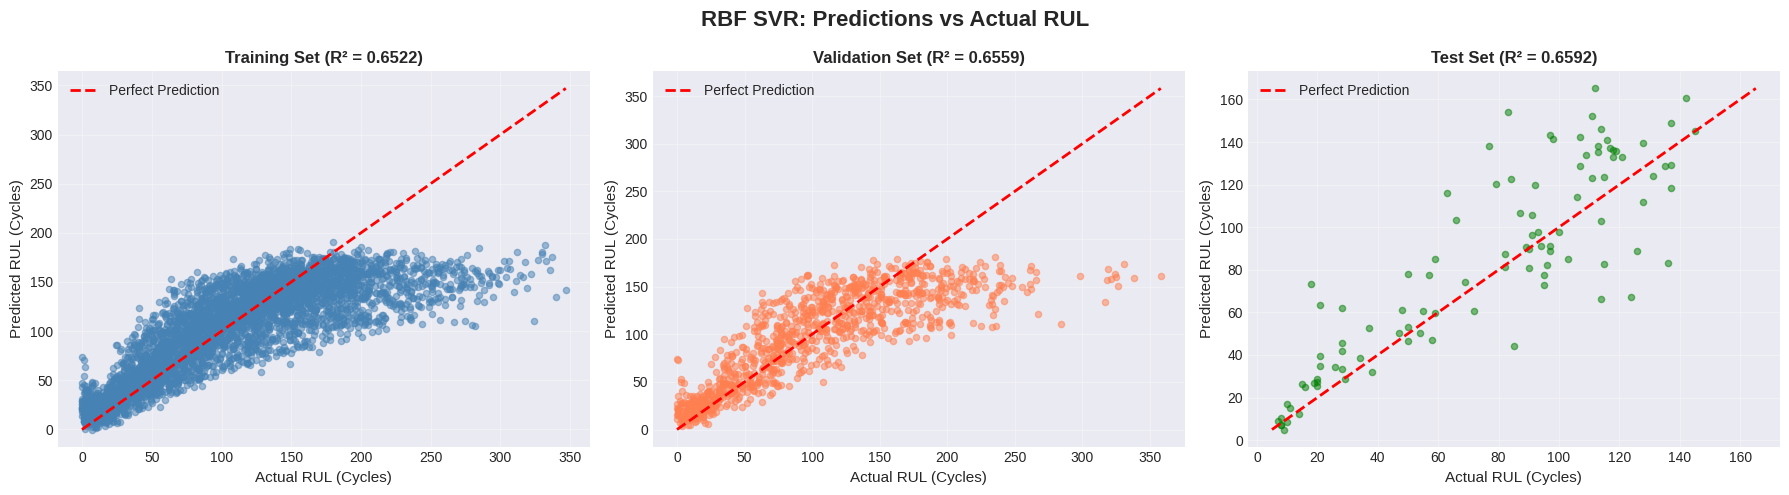

✅ Predictions visualization created!


In [12]:
# Create comparison plots for the best model (RBF)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RBF SVR: Predictions vs Actual RUL', fontsize=16, fontweight='bold')

# Training set
axes[0].scatter(y_train_split, y_train_pred_rbf, alpha=0.5, s=20, color='steelblue')
min_val = min(min(y_train_split), min(y_train_pred_rbf))
max_val = max(max(y_train_split), max(y_train_pred_rbf))
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual RUL (Cycles)', fontsize=11)
axes[0].set_ylabel('Predicted RUL (Cycles)', fontsize=11)
axes[0].set_title(f'Training Set (R² = {results["RBF SVR"]["Train"]["R²"]:.4f})', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation set
axes[1].scatter(y_val_split, y_val_pred_rbf, alpha=0.5, s=20, color='coral')
min_val = min(min(y_val_split), min(y_val_pred_rbf))
max_val = max(max(y_val_split), max(y_val_pred_rbf))
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual RUL (Cycles)', fontsize=11)
axes[1].set_ylabel('Predicted RUL (Cycles)', fontsize=11)
axes[1].set_title(f'Validation Set (R² = {results["RBF SVR"]["Val"]["R²"]:.4f})', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Test set
axes[2].scatter(y_test, y_test_pred_rbf, alpha=0.5, s=20, color='green')
min_val = min(min(y_test), min(y_test_pred_rbf))
max_val = max(max(y_test), max(y_test_pred_rbf))
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual RUL (Cycles)', fontsize=11)
axes[2].set_ylabel('Predicted RUL (Cycles)', fontsize=11)
axes[2].set_title(f'Test Set (R² = {results["RBF SVR"]["Test"]["R²"]:.4f})', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Predictions visualization created!")

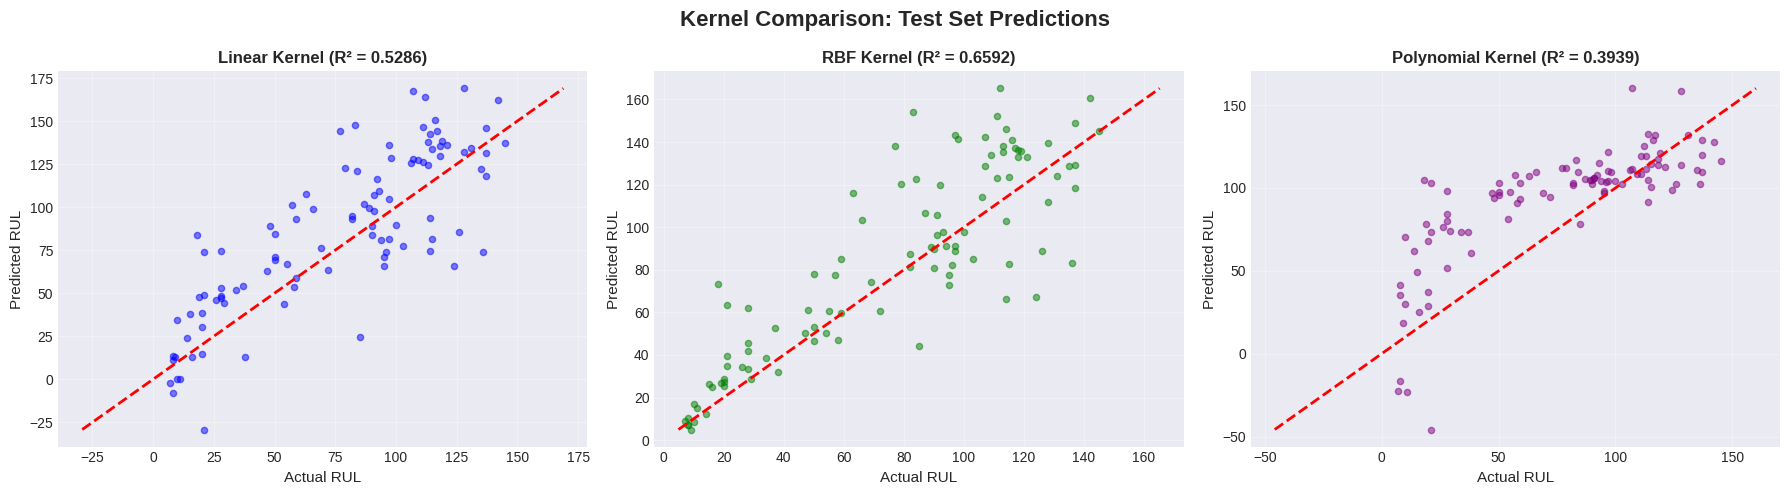

✅ Kernel comparison visualization created!


In [13]:
# Compare all three kernels on test set
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Kernel Comparison: Test Set Predictions', fontsize=16, fontweight='bold')

# Linear
axes[0].scatter(y_test, y_test_pred_linear, alpha=0.5, s=20, color='blue')
min_val = min(min(y_test), min(y_test_pred_linear))
max_val = max(max(y_test), max(y_test_pred_linear))
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[0].set_xlabel('Actual RUL', fontsize=11)
axes[0].set_ylabel('Predicted RUL', fontsize=11)
axes[0].set_title(f'Linear Kernel (R² = {results["Linear SVR"]["Test"]["R²"]:.4f})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# RBF
axes[1].scatter(y_test, y_test_pred_rbf, alpha=0.5, s=20, color='green')
min_val = min(min(y_test), min(y_test_pred_rbf))
max_val = max(max(y_test), max(y_test_pred_rbf))
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[1].set_xlabel('Actual RUL', fontsize=11)
axes[1].set_ylabel('Predicted RUL', fontsize=11)
axes[1].set_title(f'RBF Kernel (R² = {results["RBF SVR"]["Test"]["R²"]:.4f})', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Polynomial
axes[2].scatter(y_test, y_test_pred_poly, alpha=0.5, s=20, color='purple')
min_val = min(min(y_test), min(y_test_pred_poly))
max_val = max(max(y_test), max(y_test_pred_poly))
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[2].set_xlabel('Actual RUL', fontsize=11)
axes[2].set_ylabel('Predicted RUL', fontsize=11)
axes[2].set_title(f'Polynomial Kernel (R² = {results["Polynomial SVR"]["Test"]["R²"]:.4f})', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Kernel comparison visualization created!")

## Step 11: Hyperparameter Tuning (Optional but Important!)

Let's tune the hyperparameters to improve performance. We'll use **GridSearchCV** to find the best combination.

### What is GridSearchCV?
- Tests all combinations of hyperparameters
- Uses cross-validation to evaluate each combination
- Returns the best hyperparameters

### Note:
This can be slow! We'll use a smaller grid for demonstration.

In [14]:
# Hyperparameter tuning for RBF SVR
# We'll search over a small grid to save time

print("🔍 Tuning hyperparameters for RBF SVR...")
print("⚠️  This may take a few minutes...")
print("=" * 80)

# Define parameter grid
param_grid = {
    'C': [0.1, 1.0, 10.0],
    'epsilon': [0.01, 0.1, 1.0],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

# Create base model
svr_base = SVR(kernel='rbf')

# Perform grid search with cross-validation
# cv=3 means 3-fold cross-validation (faster than default 5-fold)
print("\n⏳ Running GridSearchCV (this will test 3×3×4 = 36 combinations)...")
start_time = time.time()

grid_search = GridSearchCV(
    svr_base, 
    param_grid, 
    cv=3,  # 3-fold cross-validation
    scoring='r2',  # Use R² as the scoring metric
    n_jobs=-1,  # Use all CPU cores
    verbose=1  # Show progress
)

grid_search.fit(X_train_split, y_train_split)

tuning_time = time.time() - start_time

print(f"\n✅ Hyperparameter tuning completed in {tuning_time:.2f} seconds!")
print(f"\n🏆 Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📊 Best Cross-Validation R²: {grid_search.best_score_:.4f}")

🔍 Tuning hyperparameters for RBF SVR...
⚠️  This may take a few minutes...

⏳ Running GridSearchCV (this will test 3×3×4 = 36 combinations)...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

✅ Hyperparameter tuning completed in 7.89 seconds!

🏆 Best Parameters:
   C: 10.0
   epsilon: 1.0
   gamma: auto

📊 Best Cross-Validation R²: 0.7033


In [15]:
# Evaluate the tuned model
best_svr = grid_search.best_estimator_

# Make predictions with tuned model
y_test_pred_tuned = best_svr.predict(X_test_scaled)

# Calculate metrics
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned))
tuned_mae = mean_absolute_error(y_test, y_test_pred_tuned)
tuned_r2 = r2_score(y_test, y_test_pred_tuned)

print("📊 Tuned Model Performance:")
print("=" * 80)
print(f"   Test RMSE: {tuned_rmse:.2f}")
print(f"   Test MAE: {tuned_mae:.2f}")
print(f"   Test R²: {tuned_r2:.4f}")

print(f"\n📊 Comparison with Default RBF SVR:")
print(f"   Default R²: {results['RBF SVR']['Test']['R²']:.4f}")
print(f"   Tuned R²:   {tuned_r2:.4f}")
improvement = (tuned_r2 - results['RBF SVR']['Test']['R²']) / results['RBF SVR']['Test']['R²'] * 100
print(f"   Improvement: {improvement:+.2f}%")

📊 Tuned Model Performance:
   Test RMSE: 25.55
   Test MAE: 19.03
   Test R²: 0.6221

📊 Comparison with Default RBF SVR:
   Default R²: 0.6592
   Tuned R²:   0.6221
   Improvement: -5.64%


## Step 12: Understanding Support Vectors

Let's examine the support vectors to understand what the model considers "important" data points.

In [16]:
# Analyze support vectors from the best model
print("📊 Support Vector Analysis (Best Model):")
print("=" * 80)

# Get support vector indices
sv_indices = svr_rbf.support_
n_support_vectors = len(sv_indices)
n_total = len(X_train_split)

print(f"\n📈 Support Vector Statistics:")
print(f"   Total training samples: {n_total:,}")
print(f"   Number of support vectors: {n_support_vectors:,}")
print(f"   Percentage: {n_support_vectors/n_total*100:.2f}%")

# Get the actual RUL values for support vectors
sv_rul_values = y_train_split.iloc[sv_indices].values

print(f"\n📊 RUL Distribution of Support Vectors:")
print(f"   Min RUL: {sv_rul_values.min():.2f}")
print(f"   Max RUL: {sv_rul_values.max():.2f}")
print(f"   Mean RUL: {sv_rul_values.mean():.2f}")
print(f"   Std RUL: {sv_rul_values.std():.2f}")

print(f"\n📊 RUL Distribution of All Training Data:")
print(f"   Min RUL: {y_train_split.min():.2f}")
print(f"   Max RUL: {y_train_split.max():.2f}")
print(f"   Mean RUL: {y_train_split.mean():.2f}")
print(f"   Std RUL: {y_train_split.std():.2f}")

print("\n💡 Interpretation:")
print("   - Support vectors are the 'hard' examples (outside epsilon-tube)")
print("   - These are the points the model focuses on learning")
print("   - Only these points are stored, making the model memory-efficient")

📊 Support Vector Analysis (Best Model):

📈 Support Vector Statistics:
   Total training samples: 4,000
   Number of support vectors: 3,983
   Percentage: 99.58%

📊 RUL Distribution of Support Vectors:
   Min RUL: 0.00
   Max RUL: 347.00
   Mean RUL: 108.28
   Std RUL: 69.09

📊 RUL Distribution of All Training Data:
   Min RUL: 0.00
   Max RUL: 347.00
   Mean RUL: 108.12
   Std RUL: 69.09

💡 Interpretation:
   - Support vectors are the 'hard' examples (outside epsilon-tube)
   - These are the points the model focuses on learning
   - Only these points are stored, making the model memory-efficient


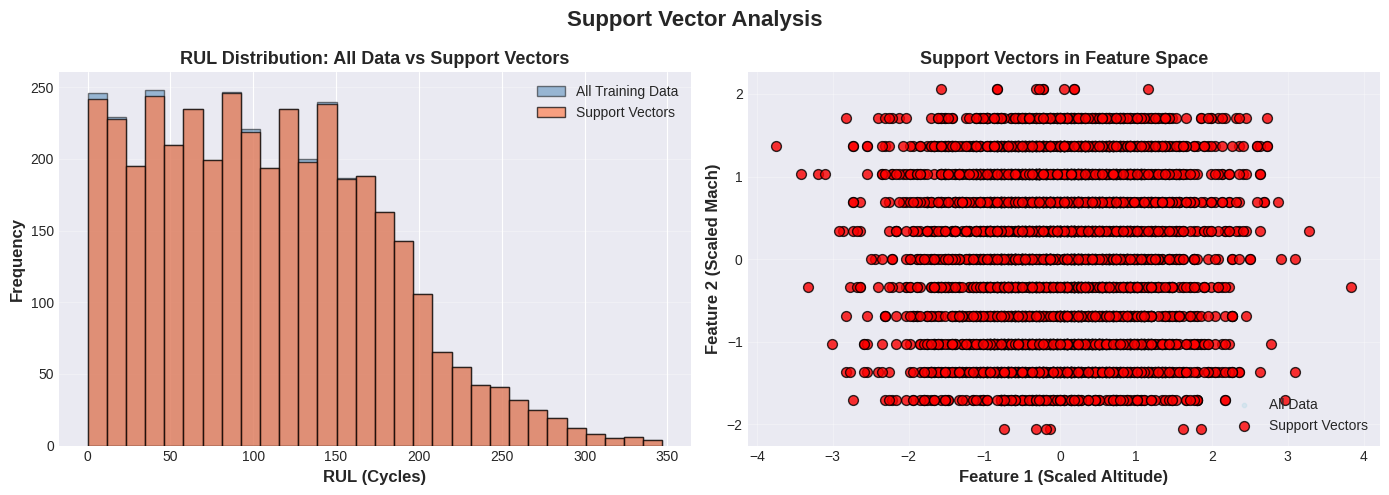

✅ Support vector visualization created!


In [17]:
# Visualize support vector distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Support Vector Analysis', fontsize=16, fontweight='bold')

# Histogram: All data vs Support vectors
axes[0].hist(y_train_split.values, bins=30, alpha=0.5, label='All Training Data', color='steelblue', edgecolor='black')
axes[0].hist(sv_rul_values, bins=30, alpha=0.7, label='Support Vectors', color='coral', edgecolor='black')
axes[0].set_xlabel('RUL (Cycles)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('RUL Distribution: All Data vs Support Vectors', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Scatter: Support vectors in feature space (using first two features)
axes[1].scatter(X_train_split[:, 0], X_train_split[:, 1], alpha=0.3, s=10, label='All Data', color='lightblue')
axes[1].scatter(X_train_split[sv_indices, 0], X_train_split[sv_indices, 1], 
               alpha=0.8, s=50, label='Support Vectors', color='red', edgecolor='black', linewidth=1)
axes[1].set_xlabel('Feature 1 (Scaled Altitude)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Feature 2 (Scaled Mach)', fontsize=12, fontweight='bold')
axes[1].set_title('Support Vectors in Feature Space', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Support vector visualization created!")

## 🎓 Summary and Key Takeaways

Congratulations! You've successfully built and evaluated SVR models!

### ✅ What You've Learned:

1. **SVM/SVR Basics**:
   - Support Vector Regression for regression tasks
   - Epsilon-tube concept (tolerance margin)
   - Support vectors (important data points)
   - Memory-efficient (only stores support vectors)

2. **Kernel Functions**:
   - **Linear**: Simple, fast, linear relationships
   - **RBF**: Most common, handles non-linear patterns
   - **Polynomial**: For polynomial relationships
   - Kernel trick allows non-linear modeling

3. **Hyperparameters**:
   - **C**: Regularization (balance fit vs simplicity)
   - **epsilon**: Tube width (tolerance for errors)
   - **gamma**: RBF kernel reach (only for RBF)
   - Tuning is important for good performance

4. **Loss Function**:
   - **Epsilon-insensitive loss**: Ignores small errors
   - Only penalizes errors outside epsilon-tube
- Different from MSE (used in Linear Regression)

5. **Model Training & Evaluation**:
   - Feature scaling is CRITICAL for SVR
   - SVR can be slower than Linear Regression
   - Can handle non-linear relationships
   - Good for complex patterns

### 📚 Key Concepts:

- **Support Vectors**: Data points that define the model
- **Epsilon-Tube**: Tolerance zone (errors inside = 0 loss)
- **Kernel Trick**: Transform data to higher dimensions
- **Hyperparameter Tuning**: Finding best C, epsilon, gamma
- **Feature Scaling**: Essential for distance-based algorithms

### 🔄 SVR vs Linear Regression:

| Aspect | Linear Regression | SVR |
|--------|------------------|-----|
| **Speed** | Very Fast | Slower |
| **Linearity** | Linear only | Can be non-linear (with kernel) |
| **Interpretability** | High | Lower |
| **Memory** | Stores all data | Only support vectors |
| **Outliers** | Sensitive | More robust |
| **Scaling** | Helpful | Critical |
| **Hyperparameters** | Few | Many (C, epsilon, gamma, kernel) |

### 🚀 Next Steps:

1. **Try Different Hyperparameters**:
   - Experiment with different C, epsilon, gamma values
   - Try different kernels
   - Use larger parameter grids

2. **Feature Engineering**:
   - Create new features
   - Select most important features
   - Remove redundant features

3. **Try Other Models**:
   - Random Forest
   - Gradient Boosting
   - Neural Networks
   - Compare all models

4. **Advanced Techniques**:
   - Use full dataset (not sampled)
   - Cross-validation
   - Ensemble methods

### 💡 Remember:

- **Always scale features** before using SVR
- **RBF kernel** is a good default choice
- **Hyperparameter tuning** can significantly improve performance
- **Support vectors** show which data points matter
- **SVR is slower** but can capture non-linear patterns

---

**Great job completing this tutorial! 🎉🤖**

## 📝 Practice Exercises

Try these exercises to reinforce your learning:

1. **Experiment with Epsilon**:
   - Try epsilon = 0.01, 0.1, 1.0, 10.0
   - Observe how number of support vectors changes
   - See how performance changes

2. **Experiment with C**:
   - Try C = 0.01, 0.1, 1.0, 10.0, 100.0
   - Observe overfitting vs underfitting
   - Check training vs validation performance

3. **Compare Kernels**:
   - Train with linear, RBF, and polynomial kernels
   - Compare training time
   - Compare performance
   - Choose the best for your data

4. **Full Dataset Training**:
   - Remove the sampling step
   - Train on full dataset
   - Compare performance (may be better!)
   - Note: This will be slower!

5. **Feature Selection**:
   - Use only temperature sensors
   - Use only pressure sensors
   - Compare performance
   - Find optimal feature set

Good luck! 🎯